In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
from google.colab import files
uploaded = files.upload()

Saving spam_ham_dataset.csv to spam_ham_dataset.csv


In [51]:
data = pd.read_csv("spam_ham_dataset.csv", sep=",")
data = data[['label', 'text']].rename(columns={'text': 'message'})

print("Total Emails:", len(data))
print(data.head())

Total Emails: 5171
  label                                            message
0   ham  Subject: enron methanol ; meter # : 988291\r\n...
1   ham  Subject: hpl nom for january 9 , 2001\r\n( see...
2   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...
3  spam  Subject: photoshop , windows , office . cheap ...
4   ham  Subject: re : indian springs\r\nthis deal is t...


In [52]:
data['label'] = data['label'].map({'ham':0,'spam':1})

X = data['message']
y = data['label']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 4136
Testing Data: 1035


In [54]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [55]:
model = LinearSVC()

model.fit(X_train_vec, y_train)

LinearSVC()

In [56]:
y_pred = model.predict(X_test_vec)

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9903381642512077


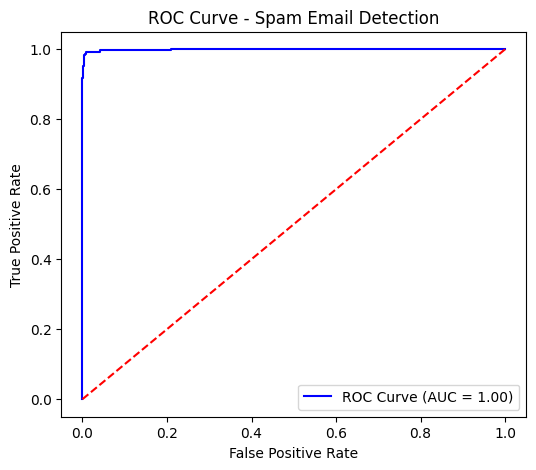

In [61]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_score = model.decision_function(X_test_vec)

fpr, tpr, thresholds = roc_curve(y_test, y_score)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Spam Email Detection")

plt.legend()

plt.show()

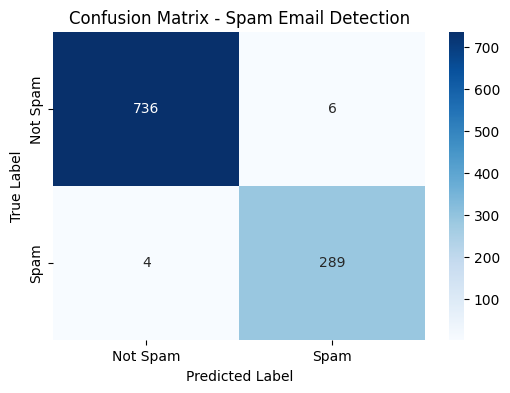

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Not Spam","Spam"],
            yticklabels=["Not Spam","Spam"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix - Spam Email Detection")

plt.show()

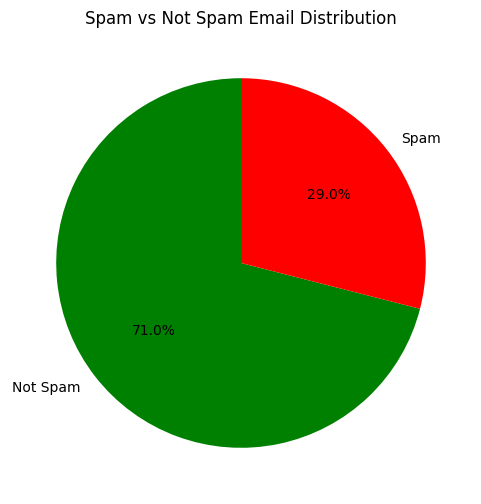

In [64]:
plt.figure(figsize=(6,6))

plt.pie(values,
        labels=labels,
        colors=['green','red'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Spam vs Not Spam Email Distribution")

plt.show()

In [65]:
total_messages = len(data)
counts = data['label'].value_counts()

spam = counts[1]
not_spam = counts[0]

print("Total Messages in Dataset:", total_messages)
print("Not Spam Messages:", not_spam)
print("Spam Messages:", spam)

Total Messages in Dataset: 5171
Not Spam Messages: 3672
Spam Messages: 1499
